# 📈 Layer Global Graph Metrics Analysis – HCB & Naples Cohorts

This analysis compares **global graph metrics** derived from brain connectivity networks across clinical groups (**Control vs EM**) and layers (**FA, GM & rsfMRI**) for both **HCB** and **Naples** cohorts.

---

## 🔄 What this analysis does

### 1. 🧬 Load clinical data
- Reads `.csv` files containing clinical information per subject.
- Renames subject ID columns to `'Subject'`.
- Creates a new `'Group'` column using:
  - `controls_ms` (for HCB)
  - `GROUP` (for Naples)
  - Values: `0 → Control`, `1 → EM`

### 2. 📊 Load and tag global graph metrics
- Loads `.xlsx` files with **global metrics** (one row per subject).
- Adds a `'Layer'` column to distinguish between:
  - FA, GM, rsfMRI
- Concatenates all layers into one DataFrame.

### 3. 🔗 Merge graph metrics with clinical data
- Inner join on `'Subject'` to retain only valid individuals.
- Final merged dataset includes metrics + group label.

### 4. 📦 Metrics included
The following metrics are computed for each subject and each network layer:
- **density**: proportion of present edges relative to all possible edges
- **average_clustering**: average of local clustering coefficients
- **global_efficiency**: how efficiently information is exchanged over the network
- **average_shortest_path**: mean shortest path between all pairs of nodes

---

## 📈 Visualization: Boxplots by Layer and Group

Using `FacetGrid` (seaborn), one boxplot per metric is displayed across all layers. These allow quick inspection of **differences between clinical groups** (Control vs EM) within each layer.

---

## 📊 Summary Statistics

The pipeline generates a summary table with:
- **Mean and standard deviation** for each metric
- Stratified by **Layer** and **Group**

---

## 🔍 Correlation with Clinical Scores

The pipeline also computes **Pearson correlations** between:
- Graph metrics (e.g., density, efficiency)
- Clinical variables (e.g., `EDSS`, `Disease Duration (DD)`)

> This helps explore associations between network topology and clinical severity.

---

## ✅ Outputs

- `df_merged_hcb`, `df_merged_naples`: merged DataFrames with clinical + metric data
- `summary_hcb`, `summary_naples`: group-level metric means & SDs
- `corrs_hcb`, `corrs_naples`: correlation matrices (metric × clinical variable)
- 📊 Visualizations: boxplots for each metric by group and layer


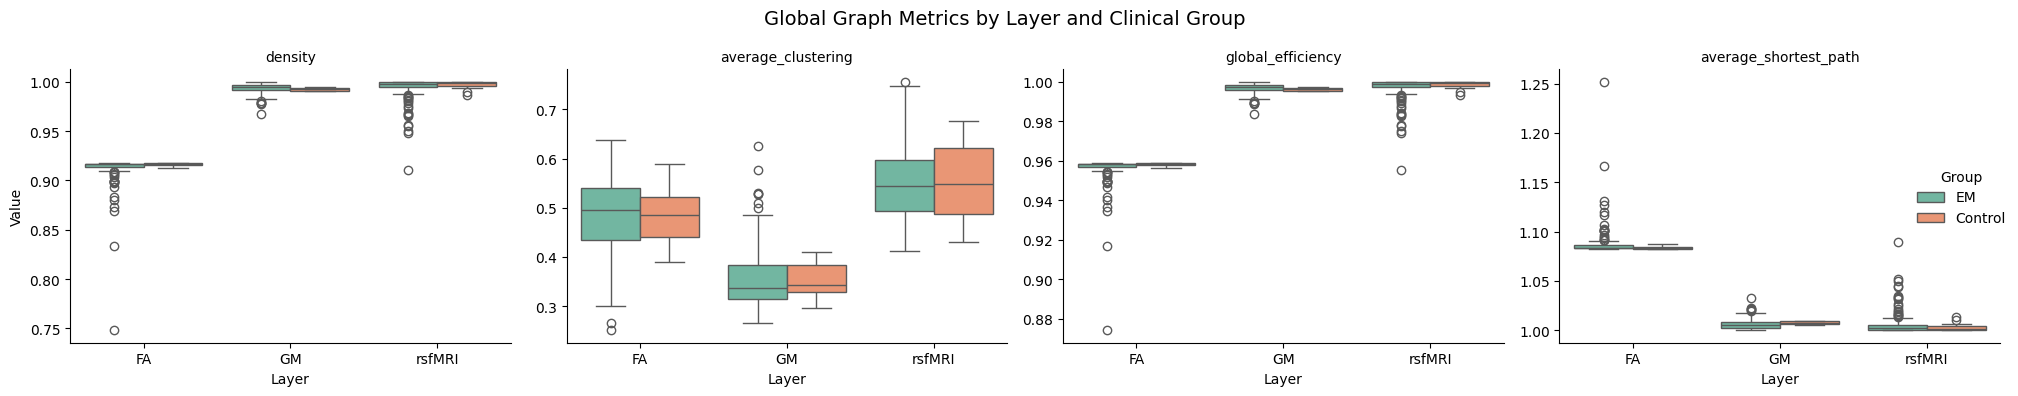

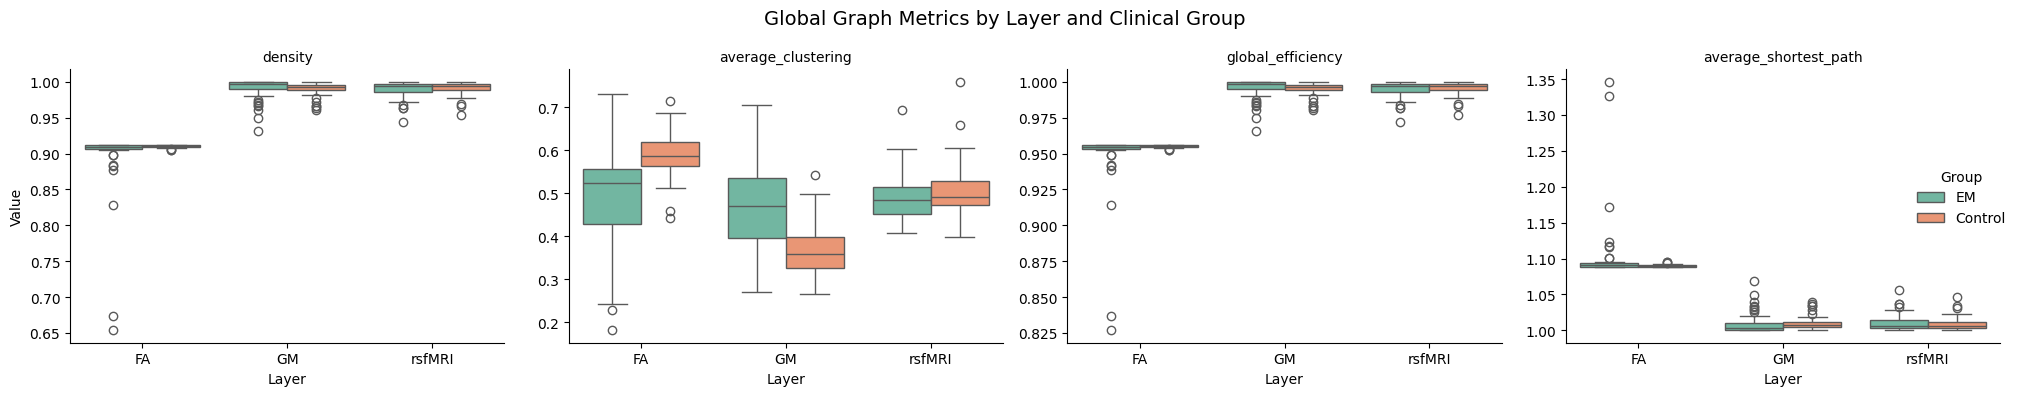

In [13]:
import os
#import numpy as np
import pandas as pd
#import networkx as nx
#from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns 

# ==============================================
# 🧠 GRAPH METRICS ANALYSIS - HCB & Naples
#   (clinical data in .pkl, graph metrics in .xls/.xlsx)
# ==============================================

# ================================
# Load clinical data
# ================================
def load_clinical_data(hcb_csv, naples_csv,
                       hcb_id_col='id', naples_id_col='ID'):
    """
    Load clinical DataFrames from .csv files,
    rename their ID columns to 'Subject', and standardize Group.
    """
    df_hcb = pd.read_csv(hcb_csv).reset_index()
    df_naples = pd.read_csv(naples_csv).reset_index()

    df_hcb = df_hcb.rename(columns={hcb_id_col: 'Subject'})
    df_naples = df_naples.rename(columns={naples_id_col: 'Subject'})

    df_hcb['Group'] = df_hcb['controls_ms'].map({0: 'Control', 1: 'EM'})
    df_naples['Group'] = df_naples['GROUP'].map({0: 'Control', 1: 'EM'})

    return df_hcb, df_naples

# ================================
# Load & tag global graph metrics
# ================================
def load_global_graph_data(paths_dict):
    """
    Load global‐graph metrics from Excel files,
    ensure 'Subject' is a column, and add a 'Layer' tag.
    """
    dfs = []
    for layer, path in paths_dict.items():
        # Read the sheet, taking the first column as the Subject index
        df = pd.read_excel(path, index_col=0).reset_index()
        # After reset_index(), the index name (Subject) becomes a column
        # If for some reason it's called 'index', rename it:
        if 'index' in df.columns:
            df = df.rename(columns={'index': 'Subject'})
        df['Layer'] = layer
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# ================================
# Filter & merge data
# ================================
def merge_with_clinical(global_df, clinical_df):
    """
    Keep only clinical entries whose Subject appears in global_df,
    then inner-merge on 'Subject'.
    """
    valid = set(global_df['Subject'])
    clinical_filt = clinical_df[clinical_df['Subject'].isin(valid)].copy()
    return global_df.merge(clinical_filt, on='Subject', how='inner')

# ====================================
# Plot global metrics by group
# ====================================
def plot_metrics_facet_by_metric(df):
    """
    Plots boxplots of each global graph metric across layers and groups,
    with one subplot per metric, all arranged in a single row.

    Parameters:
    - df: DataFrame containing global metrics, layers and group labels.
    """

    # Select relevant columns
    metric_cols = ['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']
    base_cols = ['Subject', 'Layer', 'Group']
    df_clean = df[base_cols + metric_cols].copy()

    # Melt to long format
    melted = df_clean.melt(
        id_vars=base_cols,
        var_name='Metric',
        value_name='Value'
    )

    # Create FacetGrid with one plot per metric
    g = sns.FacetGrid(melted, col='Metric', col_order=metric_cols,
                      height=4, aspect=1.2, sharey=False)

    # Plot boxplots with hue as clinical group and style per Layer
    g.map_dataframe(sns.boxplot, x='Layer', y='Value', hue='Group', palette='Set2')

    # Improve layout
    g.set_titles(col_template="{col_name}")
    g.set_axis_labels("Layer", "Value")
    g.add_legend(title='Group')
    plt.subplots_adjust(top=0.85)
    g.fig.suptitle("Global Graph Metrics by Layer and Clinical Group", fontsize=14)
    plt.tight_layout()
    plt.show()

# ====================================
# Summarize global metrics
# ====================================
def summarize_global_metrics(df):
    # Exclde non-numeric columns
    base_cols = ['Subject', 'Layer', 'Group']
    #metric_cols = [col for col in df.columns
    #               if col not in base_cols and pd.api.types.is_numeric_dtype(df[col])]
    metric_cols = ['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']

    return df.groupby(['Layer', 'Group'])[metric_cols].agg(['mean', 'std'])

# =========================================
# Correlate metrics with clinical vars
# =========================================
def correlate_with_clinical(global_df, variables=['EDSS', 'DD']):
    """
    Computes Pearson correlation between graph metrics and clinical variables.

    Parameters:
        global_df: DataFrame with graph metrics and clinical data.
        variables: List of clinical variables (column names) to correlate.

    Returns:
        DataFrame: graph metrics × clinical variables correlation values.
    """
    results = {}
    metrics = ['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']

    for metric in metrics:
        for var in variables:
            corr = global_df[[metric, var]].corr().iloc[0, 1]
            results[(metric, var)] = corr

    return pd.Series(results).unstack()


# =======================================
# Usage
# =======================================
# Paths to clinical .pkl files (adjust ID column names if needed)
hcb_clinic_csv    = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/CLINIC_HCB_B.csv"
naples_clinic_csv = "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/CLINIC_Naples_B.csv"

# Paths to Excel graph‐metrics
hcb_paths_global = {
    "FA":     "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/graph-metrics_FA_matrices_median_re/global_graph_metrics_FA.xlsx",
    "GM":     "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/graph-metrics_GM_matrices_median_re/global_graph_metrics_GM.xlsx",
    "rsfMRI": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_HCB/graph_metrics/graph-metrics_rsfMRI_matrices_median_re/global_graph_metrics_rsfMRI.xlsx",
   
}
naples_paths_global = {
    "FA":     "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/graph-metrics_FA_matrices_median_re/global_graph_metrics_FA.xlsx",
    "GM":     "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/graph-metrics_GM_matrices_median_re/global_graph_metrics_GM.xlsx",
    "rsfMRI": "F:/Cursos/UOC Master Bio Inf. Est/M0.209 - UOC - TFM - Bio ML - Grafos/DATOS/MULTILAYER/DADES_NAPLES/graph_metrics/graph-metrics_rsfMRI_matrices_median_re/global_graph_metrics_rsfMRI.xlsx",
  
}


# Load clinical and graph data
df_hcb_clinic, df_naples_clinic = load_clinical_data(
    hcb_clinic_csv, naples_clinic_csv,
    hcb_id_col='id', naples_id_col='ID'  # adjust to your actual column names
)
df_global_hcb    = load_global_graph_data(hcb_paths_global)
df_global_naples = load_global_graph_data(naples_paths_global)

# Filter & merge
df_merged_hcb    = merge_with_clinical(df_global_hcb, df_hcb_clinic)
df_merged_naples = merge_with_clinical(df_global_naples, df_naples_clinic)

# Plot comparisons
plot_metrics_facet_by_metric(df_merged_hcb)
plot_metrics_facet_by_metric(df_merged_naples)

# Summaries & Correlations
summary_hcb    = summarize_global_metrics(df_merged_hcb)
summary_naples = summarize_global_metrics(df_merged_naples)
corrs_hcb  = correlate_with_clinical(df_merged_hcb, variables=['dd', 'edss'])
corrs_naples  = correlate_with_clinical(df_merged_naples, variables=['DD', 'EDSS'])


In [14]:
# Display results
print("HCB Summary\n", summary_hcb)
#summary_hcb.info()
#summary_hcb.describe

HCB Summary
                  density           average_clustering            \
                    mean       std               mean       std   
Layer  Group                                                      
FA     Control  0.916218  0.001422           0.485097  0.060916   
       EM       0.911773  0.017081           0.485182  0.075293   
GM     Control  0.992456  0.001545           0.352250  0.037570   
       EM       0.993624  0.005291           0.354757  0.064954   
rsfMRI Control  0.997076  0.003957           0.550511  0.084191   
       EM       0.993466  0.012105           0.548746  0.073552   

               global_efficiency           average_shortest_path            
                            mean       std                  mean       std  
Layer  Group                                                                
FA     Control          0.958109  0.000711              1.083782  0.001422  
       EM               0.955886  0.008541              1.088227  0.017081 

# 🧠 Global Graph Metric Comparison (HCB Cohort)

This summary compares average values of global graph metrics between **Control** and **MS (EM)** subjects across five network configurations: **FA**, **GM** & **rsfMRI**.

Each metric is interpreted to reflect potential disruptions in network topology associated with MS.

---

## 🟦 FA (Structural Connectivity)

| Metric               | Control  | EM       | Δ (C − EM)   | Interpretation                              |
|----------------------|----------|----------|--------------|----------------------------------------------|
| **Density**          | 0.9162   | 0.9118   | 🔻 −0.0044   | Slightly reduced connectivity in MS         |
| **Clustering**       | 0.4851   | 0.4852   | 🔺 +0.0001   | No meaningful difference                    |
| **Efficiency**       | 0.9581   | 0.9559   | 🔻 −0.0022   | Slightly less integration in MS             |
| **Shortest Path**    | 1.0838   | 1.0882   | 🔺 +0.0044   | Longer paths (reduced efficiency) in MS     |

✅ *MS networks are slightly less dense and efficient structurally.*

---

## 🟩 GM (Morphological Connectivity)

| Metric               | Control  | EM       | Δ (C − EM)   | Interpretation                              |
|----------------------|----------|----------|--------------|----------------------------------------------|
| **Density**          | 0.9925   | 0.9936   | 🔺 +0.0011   | Almost identical networks                   |
| **Clustering**       | 0.3523   | 0.3548   | 🔺 +0.0025   | Slightly higher local clustering in MS      |
| **Efficiency**       | 0.9962   | 0.9968   | 🔺 +0.0006   | Practically unchanged                       |
| **Shortest Path**    | 1.0075   | 1.0064   | 🔻 −0.0011   | No real difference                          |

✅ *GM network topology is stable and not impacted by MS.*

---

## 🟨 rsfMRI (Functional Connectivity)

| Metric               | Control  | EM       | Δ (C − EM)   | Interpretation                              |
|----------------------|----------|----------|--------------|----------------------------------------------|
| **Density**          | 0.9971   | 0.9935   | 🔻 −0.0036   | Slight loss of functional connectivity      |
| **Clustering**       | 0.5505   | 0.5487   | 🔻 −0.0018   | Slight drop in local organization in MS     |
| **Efficiency**       | 0.9985   | 0.9967   | 🔻 −0.0018   | Slight functional integration decrease      |
| **Shortest Path**    | 1.0029   | 1.0065   | 🔺 +0.0036   | Less efficient communication in MS          |

✅ *rsfMRI shows early functional signs of network disconnection in MS.*


## 🔚 Summary

- **MS subjects show consistent, albeit small, reductions** in integration, density, and clustering in FA and rsfMRI layers.
- **GM connectivity is preserved**.


In [16]:
print("\nNaples Summary\n", summary_naples)


Naples Summary
                  density           average_clustering            \
                    mean       std               mean       std   
Layer  Group                                                      
FA     Control  0.910328  0.001709           0.589004  0.053489   
       EM       0.896727  0.048938           0.499027  0.115975   
GM     Control  0.989904  0.009276           0.367770  0.059127   
       EM       0.991059  0.014424           0.465124  0.104958   
rsfMRI Control  0.991433  0.009221           0.506617  0.057585   
       EM       0.989501  0.011474           0.491910  0.052491   

               global_efficiency           average_shortest_path            
                            mean       std                  mean       std  
Layer  Group                                                                
FA     Control          0.955164  0.000854              1.089672  0.001709  
       EM               0.948364  0.024469              1.103273  0.048

# 🧠 Global Graph Metric Comparison (Naples Cohort)

This table compares the average global graph metrics between **Control** and **MS (EM)** subjects across five network types: **FA**, **GM** & **rsfMRI**.

---

## 🟦 FA (Structural Connectivity)

| Metric               | Control  | EM       | Δ (C − EM)   | Interpretation                                |
|----------------------|----------|----------|--------------|-----------------------------------------------|
| **Density**          | 0.9103   | 0.8967   | 🔻 −0.0136   | Lower structural connectivity in MS           |
| **Clustering**       | 0.5890   | 0.4990   | 🔻 −0.0900   | Drop in local connectivity             |
| **Efficiency**       | 0.9552   | 0.9484   | 🔻 −0.0068   | Slightly worse global integration             |
| **Shortest Path**    | 1.0897   | 1.1033   | 🔺 +0.0136   | Longer paths = less efficient communication   |

✅ *Structural networks in MS patients appear significantly less cohesive and efficient.*

---

## 🟩 GM (Morphological Connectivity)

| Metric               | Control  | EM       | Δ (C − EM)   | Interpretation                                |
|----------------------|----------|----------|--------------|-----------------------------------------------|
| **Density**          | 0.9899   | 0.9911   | 🔺 +0.0012   | Nearly identical                              |
| **Clustering**       | 0.3678   | 0.4651   | 🔺 +0.0973   | Higher local cohesion in MS                   |
| **Efficiency**       | 0.9950   | 0.9955   | 🔺 +0.0005   | No significant difference                     |
| **Shortest Path**    | 1.0101   | 1.0089   | 🔻 −0.0012   | Slight improvement in MS                      |

✅ *MS group shows unexpected increase in clustering — may reflect morphological reorganization.*

---

## 🟨 rsfMRI (Functional Connectivity)

| Metric               | Control  | EM       | Δ (C − EM)   | Interpretation                                |
|----------------------|----------|----------|--------------|-----------------------------------------------|
| **Density**          | 0.9914   | 0.9895   | 🔻 −0.0019   | Slightly less functional connectivity in MS   |
| **Clustering**       | 0.5066   | 0.4919   | 🔻 −0.0147   | Drop in local functional cohesion        |
| **Efficiency**       | 0.9957   | 0.9948   | 🔻 −0.0009   | Slight loss of integration                    |
| **Shortest Path**    | 1.0086   | 1.0105   | 🔺 +0.0019   | Longer functional paths                       |

✅ *Subtle reductions in functional connectivity and integration in MS.*

---

## 🔚 Summary (Naples)

- The **FA layer** shows the most pronounced differences between groups (notably in clustering).
- The **GM layer** surprisingly exhibits **higher clustering in MS**, possibly due to compensatory morphometric changes.


In [4]:
print("\nHCB Correlations\n", corrs_hcb.round(3))


HCB Correlations
                           dd   edss
average_clustering    -0.051 -0.071
average_shortest_path  0.020  0.025
density               -0.020 -0.025
global_efficiency     -0.020 -0.025


In [17]:
print("\nNaples Correlations\n", corrs_naples.round(3))


Naples Correlations
                           DD   EDSS
average_clustering    -0.029 -0.141
average_shortest_path  0.065  0.105
density               -0.065 -0.105
global_efficiency     -0.065 -0.105


# 📊 Correlation Between Global Graph Metrics and Clinical Variables

We computed Pearson correlations between global graph metrics and two clinical variables:
- **EDSS** (Expanded Disability Status Scale): higher values indicate greater disability.
- **DD** (Disease Duration): time (in years) since MS diagnosis.

---

## 📌 What Each Graph Metric Means

| **Metric**              | **Interpretation**                                                                 |
|-------------------------|------------------------------------------------------------------------------------|
| **Density**             | Fraction of actual connections vs. all possible connections in the graph.         |
| **Average Clustering**  | How strongly nodes form local clusters (triangles) — reflects local segregation.  |
| **Global Efficiency**   | Inverse of average path length — higher = better global information flow.         |
| **Average Shortest Path** | Average minimal path length between all node pairs — lower = more efficient.      |

---

## 🧠 HCB Cohort: Correlations with Clinical Variables

| Metric                  | `dd`      | `edss`    | Interpretation                                          |  
|-------------------------|-----------|-----------|----------------------------------------------------------|  
| `average_clustering`    | −0.051    | −0.071    | Slight reduction in clustering with greater clinical severity |  
| `average_shortest_path` | +0.020    | +0.025    | Slightly longer paths in more advanced MS               |  
| `density`               | −0.020    | −0.025    | Minimal decrease in connection density                  |  
| `global_efficiency`     | −0.020    | −0.025    | Slight reduction in global network efficiency           |

---

### General Interpretation:

- **Mild disconnection trend**: Negative correlations in `density`, `global_efficiency`, and `clustering` suggest a slight loss of global network organization with increased disease duration or severity.
- **Very weak clinical effect**: All coefficients are low (all < |0.1|), indicating no strong correlations, but hinting at gradual progression-related changes.
- **Positive `average_shortest_path`**: Indicates that communication between brain regions may require slightly longer paths in subjects with more advanced MS.

---

## 🧠 Naples Cohort: Correlations with Clinical Variables

| Metric                  | `DD`      | `EDSS`    | Interpretation                                          |  
|-------------------------|-----------|-----------|----------------------------------------------------------|  
| `average_clustering`    | −0.029    | −0.141    | Slight to moderate reduction in clustering with disease severity |  
| `average_shortest_path` | +0.065    | +0.105    | Longer paths in subjects with more advanced MS          |  
| `density`               | −0.065    | −0.105    | Mild decrease in connection density                     |  
| `global_efficiency`     | −0.065    | −0.105    | Slight loss of global network efficiency                |

---

### General Interpretation:

- **Clearer trends than in HCB**: Correlations, especially with `EDSS`, are stronger here — particularly in `clustering`, `density`, and `efficiency`.
- **Negative correlations**: Suggest a weakening of global connectivity and network integration as MS severity increases.
- **Positive `average_shortest_path`**: Indicates that information may flow through longer or less direct routes in more impaired patients.

In [6]:

from scipy.stats import ttest_ind

# ============================================
# Compare graph metrics between groups
# ============================================

def compare_groups(df, metrics=['density', 'average_clustering', 'global_efficiency', 'average_shortest_path']):
    """
    Performs independent t-tests (Control vs EM) for each graph metric within each layer.
    
    Parameters:
    - df: Merged DataFrame with graph metrics and clinical labels
    - metrics: List of global metrics to compare
    
    Returns:
    - A DataFrame with t-statistics and p-values per metric and layer
    """
    results = []
    for layer in df['Layer'].unique():
        for metric in metrics:
            sub = df[df['Layer'] == layer]
            group1 = sub[sub['Group'] == 'Control'][metric]
            group2 = sub[sub['Group'] == 'EM'][metric]
            stat, pval = ttest_ind(group1, group2, equal_var=False, nan_policy='omit')
            results.append({
                'Layer': layer,
                'Metric': metric,
                't-statistic': stat,
                'p-value': pval
            })
    return pd.DataFrame(results)

# =======================================
# Correlation across network layers
# =======================================

def inter_layer_correlations(df, metric='global_efficiency'):
    """
    Computes correlation of a given graph metric between FA, GM, and rsfMRI layers.
    
    Parameters:
    - df: Merged DataFrame
    - metric: Metric to compare across layers
    
    Returns:
    - Correlation matrix of shape (Layer x Layer)
    """
    df_wide = df.pivot(index='Subject', columns='Layer', values=metric)
    return df_wide.corr()

results_hcb = compare_groups(df_merged_hcb)
results_naples = compare_groups(df_merged_naples)

inter_corr_hcb_ge = inter_layer_correlations(df_merged_hcb, metric='global_efficiency')
inter_corr_naples_ge = inter_layer_correlations(df_merged_naples, metric='global_efficiency')

inter_corr_hcb_de = inter_layer_correlations(df_merged_hcb, metric='density')
inter_corr_naples_de = inter_layer_correlations(df_merged_naples, metric='density')

inter_corr_hcb_ac = inter_layer_correlations(df_merged_hcb, metric='average_clustering')
inter_corr_naples_ac = inter_layer_correlations(df_merged_naples, metric='average_clustering')

inter_corr_hcb_as = inter_layer_correlations(df_merged_hcb, metric='average_shortest_path')
inter_corr_naples_as = inter_layer_correlations(df_merged_naples, metric='average_shortest_path')


In [7]:
print("\nHCB group comparation\n", results_hcb.round(3))


HCB group comparation
      Layer                 Metric  t-statistic  p-value
0       FA                density        3.050    0.003
1       FA     average_clustering       -0.005    0.996
2       FA      global_efficiency        3.050    0.003
3       FA  average_shortest_path       -3.050    0.003
4       GM                density       -1.777    0.086
5       GM     average_clustering       -0.192    0.851
6       GM      global_efficiency       -1.777    0.086
7       GM  average_shortest_path        1.777    0.086
8   rsfMRI                density        2.632    0.010
9   rsfMRI     average_clustering        0.085    0.933
10  rsfMRI      global_efficiency        2.632    0.010
11  rsfMRI  average_shortest_path       -2.632    0.010


# 🧪 Group Comparison – HCB Cohort (Control vs MS)

This table shows the result of **independent t-tests** comparing global graph metrics between Control and MS subjects across all layers.

| Layer   | Metric                 | t-statistic | p-value | Significant (p<0.05)? | Interpretation |
|---------|------------------------|-------------|---------|------------------------|----------------|
| FA      | density                | +3.050      | 0.003   | ✅ Yes                 | Controls have higher structural density |
| FA      | average_clustering     | −0.005      | 0.996   | ❌ No                  | No difference in local clustering |
| FA      | global_efficiency      | +3.050      | 0.003   | ✅ Yes                 | Higher efficiency in structural networks of controls |
| FA      | average_shortest_path  | −3.050      | 0.003   | ✅ Yes                 | MS patients show longer communication paths |
| GM      | density                | −1.777      | 0.086   | ❌ No                  | Trend: lower density in MS, but not significant |
| GM      | average_clustering     | −0.192      | 0.851   | ❌ No                  | No difference |
| GM      | global_efficiency      | −1.777      | 0.086   | ❌ No                  | Similar to density, no significant difference |
| GM      | average_shortest_path  | +1.777      | 0.086   | ❌ No                  | MS may have longer paths, but trend only |
| rsfMRI  | density                | +2.632      | 0.010   | ✅ Yes                 | Controls have denser functional connectivity |
| rsfMRI  | average_clustering     | +0.085      | 0.933   | ❌ No                  | No difference |
| rsfMRI  | global_efficiency      | +2.632      | 0.010   | ✅ Yes                 | Better functional integration in controls |
| rsfMRI  | average_shortest_path  | −2.632      | 0.010   | ✅ Yes                 | Longer paths in MS functional networks |

---

## Summary

- Significant group differences are found in:
  - **FA** (structural)
  - **rsfMRI** (functional)

- Metrics most affected in MS:
  - 🔻 `density`
  - 🔻 `global_efficiency`
  - 🔺 `average_shortest_path`

- No significant differences were found in:
  - `average_clustering` in any layer
  - All metrics in **GM**, although some showed trends

In [18]:
print("\nNaples group comparation\n", results_naples.round(3))


Naples group comparation
      Layer                 Metric  t-statistic  p-value
0       FA                density        2.003    0.051
1       FA     average_clustering        5.089    0.000
2       FA      global_efficiency        2.003    0.051
3       FA  average_shortest_path       -2.003    0.051
4       GM                density       -0.487    0.627
5       GM     average_clustering       -5.841    0.000
6       GM      global_efficiency       -0.487    0.627
7       GM  average_shortest_path        0.487    0.627
8   rsfMRI                density        0.950    0.344
9   rsfMRI     average_clustering        1.368    0.174
10  rsfMRI      global_efficiency        0.950    0.344
11  rsfMRI  average_shortest_path       -0.950    0.344


# 🧪 Group Comparison – Naples Cohort (Control vs MS)

This table shows the result of **independent t-tests** comparing global graph metrics between Control and MS subjects across all layers.

| Layer   | Metric                 | t-statistic | p-value | Significant (p<0.05)? | Interpretation |
|---------|------------------------|-------------|---------|------------------------|----------------|
| FA      | density                | +2.003      | 0.051   | ❌ No (trend)          | Slightly higher density in controls (borderline) |
| FA      | average_clustering     | +5.089      | 0.000   | ✅ Yes                 | Controls show significantly higher clustering |
| FA      | global_efficiency      | +2.003      | 0.051   | ❌ No (trend)          | Slight trend toward higher efficiency in controls |
| FA      | average_shortest_path  | −2.003      | 0.051   | ❌ No (trend)          | MS patients tend to have longer paths (borderline) |
| GM      | density                | −0.487      | 0.627   | ❌ No                  | No difference |
| GM      | average_clustering     | −5.841      | 0.000   | ✅ Yes                 | MS patients show significantly lower clustering |
| GM      | global_efficiency      | −0.487      | 0.627   | ❌ No                  | No difference |
| GM      | average_shortest_path  | +0.487      | 0.627   | ❌ No                  | No difference |
| rsfMRI  | density                | +0.950      | 0.344   | ❌ No                  | No difference |
| rsfMRI  | average_clustering     | +1.368      | 0.174   | ❌ No                  | No difference |
| rsfMRI  | global_efficiency      | +0.950      | 0.344   | ❌ No                  | No difference |
| rsfMRI  | average_shortest_path  | −0.950      | 0.344   | ❌ No                  | No difference |

---

## Summary

- Significant group differences are found in:
  - ✅ **`average_clustering` in FA** (higher in controls)
  - ✅ **`average_clustering` in GM** (lower in MS)

- Metrics showing **borderline trends** (p ≈ 0.05):
  - `density`, `global_efficiency`, and `shortest_path` in FA

- No significant differences found in:
  - Any **rsfMRI** metric
  - Most **GM** and FA metrics beyond clustering

- Notable finding:
  - 🧠 **Clustering coefficient** shows opposite significant effects in FA (higher in controls) and GM (lower in MS), possibly reflecting **layer-specific disorganization** in local connectivity.



In [19]:
print("\nHCB inter correlation - Global efficiency\n", inter_corr_hcb_ge.round(3))


HCB inter correlation - Global efficiency
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.102   0.106
GM     -0.102  1.000  -0.159
rsfMRI  0.106 -0.159   1.000


# 🔄 Inter-layer Correlation – HCB (Global Efficiency)

This table shows the **Pearson correlation coefficients** between layers (FA, GM, rsfMRI) based on the `global_efficiency` metric across subjects.

|        | FA      | GM      | rsfMRI  |
|--------|---------|---------|---------|
| **FA**     | 1.000   | −0.102 | +0.106 |
| **GM**     | −0.102 | 1.000   | −0.159 |
| **rsfMRI** | +0.106 | −0.159 | 1.000   |

---

## 🧠 Interpretation

- **FA–GM**: Slight **negative correlation** (−0.102) → small decoupling between structural and morphological efficiency.
- **FA–rsfMRI**: Slight **positive correlation** (+0.106) → minor alignment between structural and functional efficiency.
- **GM–rsfMRI**: Weak **negative correlation** (−0.159) → small mismatch between morphology and function.

➡️ Overall, inter-layer correlations are **weak**, suggesting that **efficiency in one domain (e.g., structural) does not strongly predict** efficiency in others (morphological or functional). This supports the idea that **each layer captures complementary aspects** of brain organization.

In [10]:
print("\nNaples inter correlation - Global efficiency\n", inter_corr_naples_ge.round(3))


Naples inter correlation - Global efficiency
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.115   0.181
GM     -0.115  1.000  -0.138
rsfMRI  0.181 -0.138   1.000


# 🔄 Inter-layer Correlation – Naples (Global Efficiency)

This table shows the **Pearson correlation coefficients** between layers (FA, GM, rsfMRI) based on the `global_efficiency` metric across subjects.

|        | FA      | GM      | rsfMRI  |
|--------|---------|---------|---------|
| **FA**     | 1.000   | −0.115 | +0.181 |
| **GM**     | −0.115 | 1.000   | −0.138 |
| **rsfMRI** | +0.181 | −0.138 | 1.000   |

---

## 🧠 Interpretation

- **FA–GM**: Slight **negative correlation** (−0.115) → marginal decoupling between structural and morphological efficiency.
- **FA–rsfMRI**: Small **positive correlation** (+0.181) → modest structural–functional alignment.
- **GM–rsfMRI**: Weak **negative correlation** (−0.138) → functional and morphological layers may vary independently.

➡️ Similar to the HCB cohort, the correlations between layers remain **weak**, suggesting that each connectivity type (FA, GM, rsfMRI) provides **distinct information** about brain network efficiency.

In [20]:
print("\nNaples inter correlation - Density\n", inter_corr_naples_de.round(3))
print("\nNaples inter correlation - Average_clustering\n", inter_corr_naples_ac.round(3))
print("\nNaples inter correlation - Average_shortest_path\n", inter_corr_naples_as.round(3))
print("\nNaples inter correlation - Global efficiency\n", inter_corr_naples_ge.round(3))


Naples inter correlation - Density
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.115   0.181
GM     -0.115  1.000  -0.138
rsfMRI  0.181 -0.138   1.000

Naples inter correlation - Average_clustering
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.407   0.210
GM     -0.407  1.000  -0.151
rsfMRI  0.210 -0.151   1.000

Naples inter correlation - Average_shortest_path
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.115   0.181
GM     -0.115  1.000  -0.138
rsfMRI  0.181 -0.138   1.000

Naples inter correlation - Global efficiency
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.115   0.181
GM     -0.115  1.000  -0.138
rsfMRI  0.181 -0.138   1.000


# 🔄 Inter-layer Correlations – Naples Cohort

This section shows the **Pearson correlation coefficients** between connectivity layers (FA, GM, rsfMRI) for each **global graph metric** in the Naples cohort.

---

## 📐 Density

|        | FA      | GM      | rsfMRI  |
|--------|---------|---------|---------|
| **FA**     | 1.000   | −0.115 | +0.181 |
| **GM**     | −0.115 | 1.000   | −0.138 |
| **rsfMRI** | +0.181 | −0.138 | 1.000   |

**Interpretation**: Very similar to other metrics — low inter-layer correlations suggest that **density differs independently across layers**.

---

## 🧩 Average Clustering

|        | FA      | GM      | rsfMRI  |
|--------|---------|---------|---------|
| **FA**     | 1.000   | −0.407 | +0.210 |
| **GM**     | −0.407 | 1.000   | −0.151 |
| **rsfMRI** | +0.210 | −0.151 | 1.000   |

**Interpretation**:
- Moderate **negative correlation** between **FA and GM** (−0.407) suggests **opposite trends** in local clustering between structural and morphological layers.
- Mild positive FA–rsfMRI association (+0.210) hints at **local pattern alignment** in structural and functional connectivity.

---

## 🛣️ Average Shortest Path

|        | FA      | GM      | rsfMRI  |
|--------|---------|---------|---------|
| **FA**     | 1.000   | −0.115 | +0.181 |
| **GM**     | −0.115 | 1.000   | −0.138 |
| **rsfMRI** | +0.181 | −0.138 | 1.000   |

**Interpretation**: Slight positive alignment between **FA and rsfMRI**, again showing that **functional communication patterns weakly reflect structural layout**.

---

## ⚡ Global Efficiency

|        | FA      | GM      | rsfMRI  |
|--------|---------|---------|---------|
| **FA**     | 1.000   | −0.115 | +0.181 |
| **GM**     | −0.115 | 1.000   | −0.138 |
| **rsfMRI** | +0.181 | −0.138 | 1.000   |

**Interpretation**: Similar to shortest path (as expected due to inverse relationship), with **low and inconsistent correlations** across layers.

---

## 🧠 Overall Insight

- Most **inter-layer correlations are weak**, supporting the idea that each connectivity type (FA, GM, rsfMRI) **captures distinct features** of the brain network.
- The **only moderate correlation** appears in `average_clustering` between **FA and GM** (−0.407), indicating that **local structural organization may be inversely related to morphological clustering** in this cohort.



In [21]:
print("\nHCB inter correlation - Global efficiency\n", inter_corr_hcb_ge.round(3))
print("\nHCB inter correlation - Density\n", inter_corr_hcb_de.round(3))
print("\nHCB inter correlation - Average_clustering\n", inter_corr_hcb_ac.round(3))
print("\nHCB inter correlation - Average_shortest_path\n", inter_corr_hcb_as.round(3))


HCB inter correlation - Global efficiency
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.102   0.106
GM     -0.102  1.000  -0.159
rsfMRI  0.106 -0.159   1.000

HCB inter correlation - Density
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.102   0.106
GM     -0.102  1.000  -0.159
rsfMRI  0.106 -0.159   1.000

HCB inter correlation - Average_clustering
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.196   0.236
GM     -0.196  1.000  -0.140
rsfMRI  0.236 -0.140   1.000

HCB inter correlation - Average_shortest_path
 Layer      FA     GM  rsfMRI
Layer                       
FA      1.000 -0.102   0.106
GM     -0.102  1.000  -0.159
rsfMRI  0.106 -0.159   1.000


# 🔄 Inter-layer Correlations – HCB Cohort

This section presents the **Pearson correlation coefficients** between connectivity layers (FA, GM, rsfMRI) for each **global graph metric** in the HCB cohort.

---

## 📐 Density

|        | FA      | GM      | rsfMRI  |
|--------|---------|---------|---------|
| **FA**     | 1.000   | −0.102 | +0.106 |
| **GM**     | −0.102 | 1.000   | −0.159 |
| **rsfMRI** | +0.106 | −0.159 | 1.000   |

**Interpretation**: Very weak correlations across layers — suggests **density is largely independent** across modalities.

---

## 🧩 Average Clustering

|        | FA      | GM      | rsfMRI  |
|--------|---------|---------|---------|
| **FA**     | 1.000   | −0.196 | +0.236 |
| **GM**     | −0.196 | 1.000   | −0.140 |
| **rsfMRI** | +0.236 | −0.140 | 1.000   |

**Interpretation**:
- **Moderate negative correlation** between FA and GM (−0.196) implies **divergent local clustering**.
- FA–rsfMRI shows **the strongest positive correlation** in HCB (+0.236), suggesting **some shared local organization** between structure and function.

---

## 🛣️ Average Shortest Path

|        | FA      | GM      | rsfMRI  |
|--------|---------|---------|---------|
| **FA**     | 1.000   | −0.102 | +0.106 |
| **GM**     | −0.102 | 1.000   | −0.159 |
| **rsfMRI** | +0.106 | −0.159 | 1.000   |

**Interpretation**: Matches the pattern of global efficiency (inverse metric), indicating **longer paths in one modality don't predict shorter in others**.

---

## ⚡ Global Efficiency

|        | FA      | GM      | rsfMRI  |
|--------|---------|---------|---------|
| **FA**     | 1.000   | −0.102 | +0.106 |
| **GM**     | −0.102 | 1.000   | −0.159 |
| **rsfMRI** | +0.106 | −0.159 | 1.000   |

**Interpretation**: Extremely weak correlations between layers — **structural, functional, and morphological efficiency behave independently**.

---

## 🧠 Overall Insight

- Most inter-layer correlations in HCB are **very low (< |0.2|)**, highlighting **distinct connectivity profiles** for each modality.
- The only **moderate correlation** is found between **FA and rsfMRI clustering** (+0.236), suggesting a partial **local organizational match**.
- Similar patterns in density, shortest path, and efficiency confirm that **each layer captures unique topological features** of the brain network.
